In [1]:
pip install pandas numpy scikit-learn matplotlib seaborn

   ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
   - -------------------------------------- 0.5/11.3 MB 1.7 MB/s eta 0:00:07
   -- ------------------------------------- 0.8/11.3 MB 1.7 MB/s eta 0:00:07
   ---- ----------------------------------- 1.3/11.3 MB 1.9 MB/s eta 0:00:06
   ------ --------------------------------- 1.8/11.3 MB 2.0 MB/s eta 0:00:05
   -------- ------------------------------- 2.4/11.3 MB 2.1 MB/s eta 0:00:05
   ---------- ----------------------------- 2.9/11.3 MB 2.2 MB/s eta 0:00:04
   ------------ --------------------------- 3.7/11.3 MB 2.4 MB/s eta 0:00:04
   --------------- ------------------------ 4.5/11.3 MB 2.6 MB/s eta 0:00:03
   ------------------- -------------------- 5.5/11.3 MB 2.8 MB/s eta 0:00:03
   ----------------------- ---------------- 6.6/11.3 MB 3.0 MB/s eta 0:00:02
   -------------------------- ------------- 7.6/11.3 MB 3.2 MB/s eta 0:00:02
   ----------

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split 
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import make_pipeline
from sklearn.metrics import classification_report, confusion_matrix

In [5]:

df = pd.read_csv('dataset_sms_spam_v2.csv')

print("Data Berhasil Dimuat!")
print(f"Total SMS: {len(df)}")
print(f"Sebaran Label:\n{df['label'].value_counts()}")

Data Berhasil Dimuat!
Total SMS: 1143
Sebaran Label:
label
normal      569
penipuan    335
promo       239
Name: count, dtype: int64


In [6]:
X = df['Teks']
y = df['label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = make_pipeline(TfidfVectorizer(), MultinomialNB())
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('tfidfvectorizer', ...), ('multinomialnb', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None


In [7]:

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

      normal       0.94      0.93      0.93        99
    penipuan       0.97      0.89      0.93        82
       promo       0.80      0.94      0.87        48

    accuracy                           0.92       229
   macro avg       0.91      0.92      0.91       229
weighted avg       0.92      0.92      0.92       229



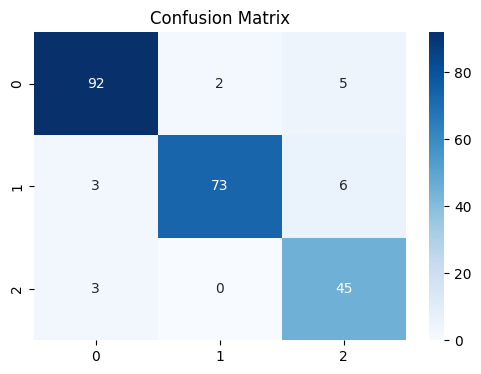

In [8]:

plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

In [9]:
import joblib

# Simpan model ke file bernama 'model_sms_pintar.joblib'
joblib.dump(model, 'model_sms_pintar.joblib')

print("Model berhasil disimpan! Cek panel file di sebelah kiri.")

Model berhasil disimpan! Cek panel file di sebelah kiri.


In [10]:
# Cek di mana model salah tebak
X_test_text = X_test.values
salah_tebak = X_test_text[y_test != y_pred]
label_asli = y_test[y_test != y_pred]
label_prediksi = y_pred[y_test != y_pred]

print(f"Jumlah kesalahan tebak: {len(salah_tebak)} dari {len(y_test)} data uji\n")

# Tampilkan 5 kesalahan pertama
for i in range(min(5, len(salah_tebak))):
    print(f"SMS: {salah_tebak[i]}")
    print(f"Asli: {label_asli.iloc[i]} | Ditebak: {label_prediksi[i]}")
    print("-" * 30)

Jumlah kesalahan tebak: 19 dari 229 data uji

SMS: Terimakasih. Paket 60 mb Anda telah aktif. Cek bonus *889#. Katalog Poin lengkap tsel.me/telkomselpoin. S&K berlaku
Asli: normal | Ditebak: promo
------------------------------
SMS: GRATIS internetan 5MB berlaku utk 7 hari hanya dg isi ulang AXISmu hari ini Rp5.000. Ayo isi ulang sekarang juga & nikmati bonusnya. Info838
Asli: penipuan | Ditebak: promo
------------------------------
SMS: Mau jajan? Gak usah kemana-mana sob, jajan online aja, terutama buat kamu yang suka nge games, cek http://tsel.me/jajanonline
Asli: promo | Ditebak: normal
------------------------------
SMS: Hayu dateng, mumpung ada ustad Fatih karim,beliau yg mengislamkan ustad Felix siaw
Asli: promo | Ditebak: normal
------------------------------
SMS: GRATIS Internetan hg 1000 MB, Nelpon 1000 Menit & 1000 SMS ke Sesama Indosat dg IsiUlang mulai 10Rb.Utk daftar ketik GRATIS kirim ke 123 (GRATIS) lalu isi Ulang
Asli: penipuan | Ditebak: promo
------------------------